# Візуалізація даних з Matplotlib

## Опис завдання

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо


In [19]:
ax = df['count'].resample('ME').mean()

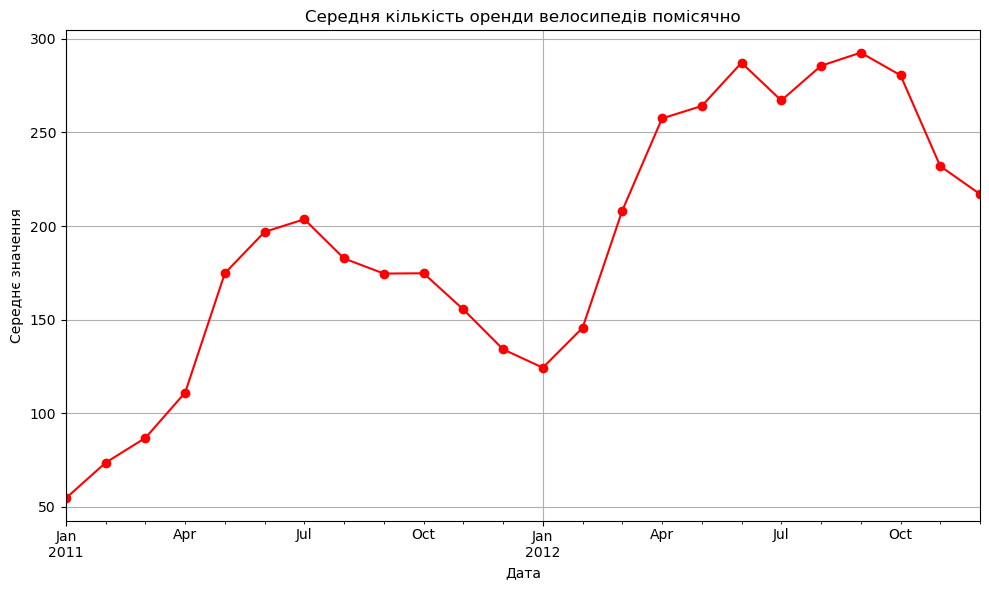

In [23]:
ax.plot(
    marker='o',
    figsize=(10, 6),
    title='Cередня кількість оренди велосипедів помісячно',
    xlabel='Дата',
    ylabel='Середнє значення',
    color = 'red',
    grid=True)
plt.tight_layout();

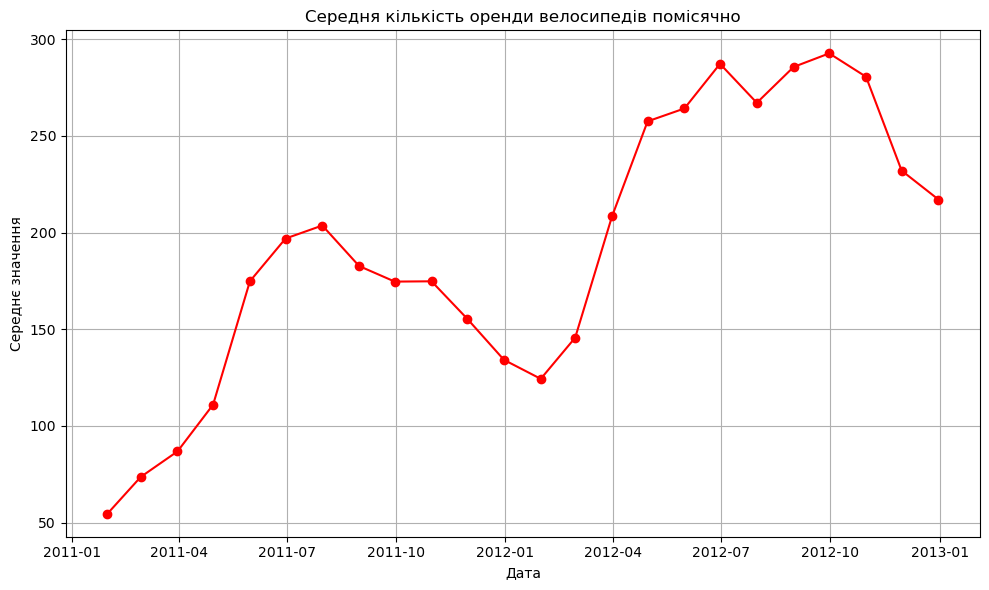

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(ax, 'o-', color = 'red')
plt.title('Cередня кількість оренди велосипедів помісячно')
plt.xlabel('Дата')
plt.ylabel('Середнє значення')
plt.grid(True)
plt.tight_layout();

Графіки відрізняються сіткою та підписами осі Х.
Мені подобається графік з Matplotlib, бо зручніше можно роздивитись середнє значення.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.


In [28]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

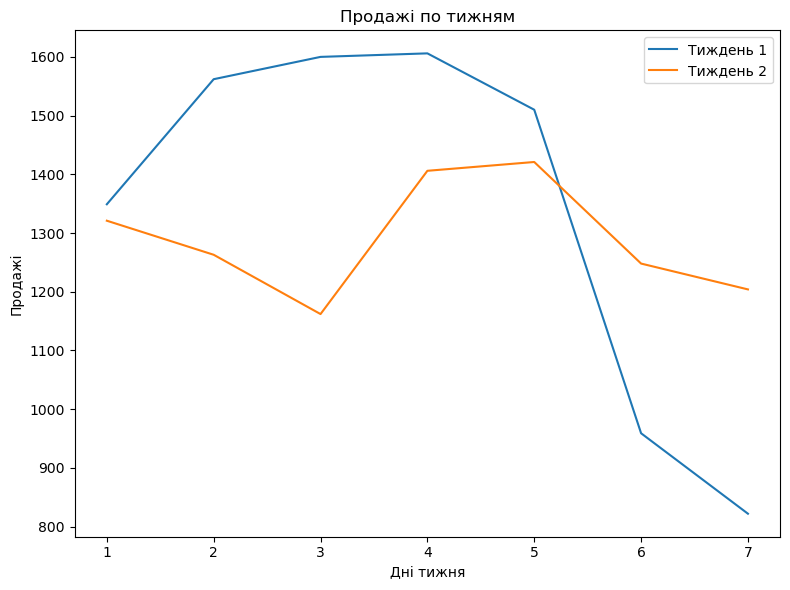

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(days, sales_week1, label ='Тиждень 1')
plt.plot(days, sales_week2, label ='Тиждень 2')
plt.title('Продажі по тижням')
plt.xlabel('Дні тижня')
plt.ylabel('Продажі')
plt.legend();
plt.tight_layout();

1. Продажі в 2 тиждень були стабільніше.
2. Можно порахувати стандартне відхилення,на 2 тижні воно буде меньшим. Це означає, що щоденні значення менше відхилялись від середнього.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.



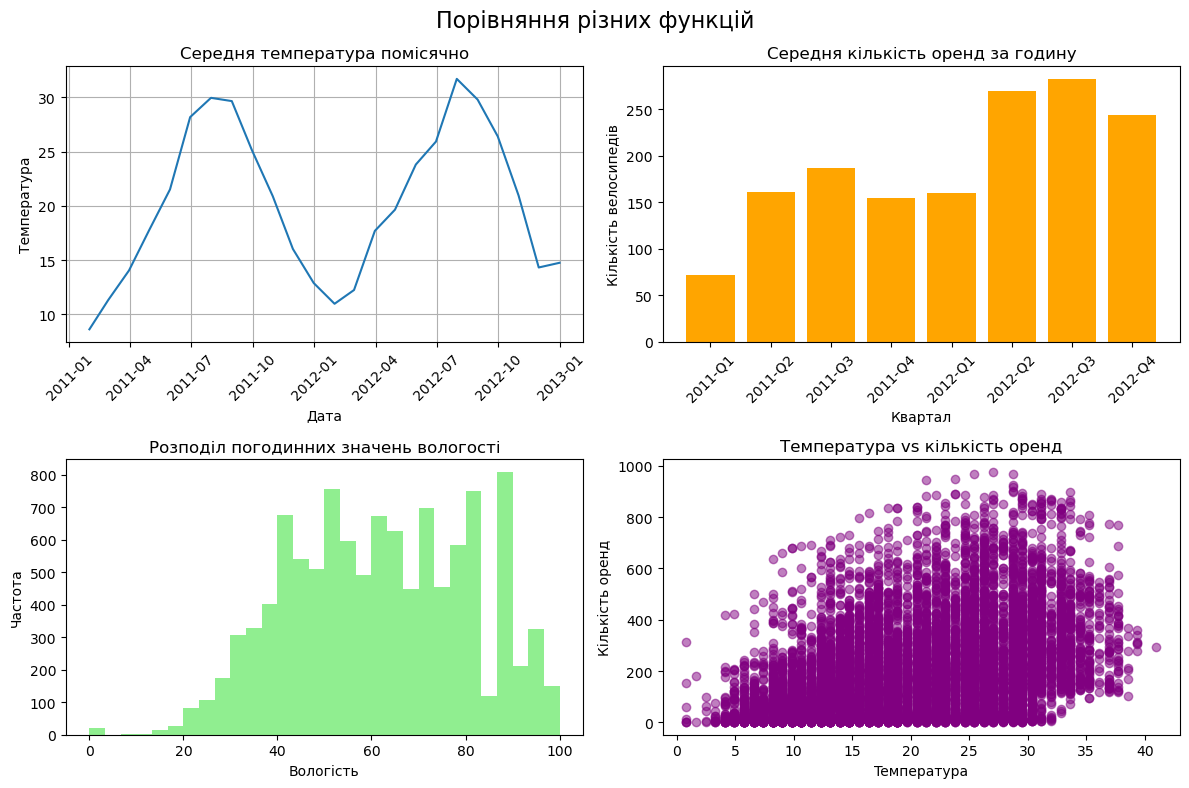

In [36]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df['temp'].resample('ME').mean())
plt.title('Cередня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
quarterly = df['count'].resample('QE').mean()
labels = [f"{d.year}-Q{d.quarter}" for d in quarterly.index]
plt.bar(labels, quarterly.values, color='orange')
plt.title('Cередня кількість оренд за годину')
plt.xlabel('Квартал')
plt.ylabel('Кількість велосипедів')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.hist(df['humidity'],bins=30, color='lightgreen')
plt.title('Розподіл погодинних значень вологості')
plt.xlabel('Вологість')
plt.ylabel('Частота')

plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha = 0.5, color='purple')
plt.title('Температура vs кількість оренд')
plt.xlabel('Teмпература')
plt.ylabel('Кількість оренд')


plt.suptitle('Порівняння різних функцій', fontsize=16)
plt.tight_layout()
plt.show();

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

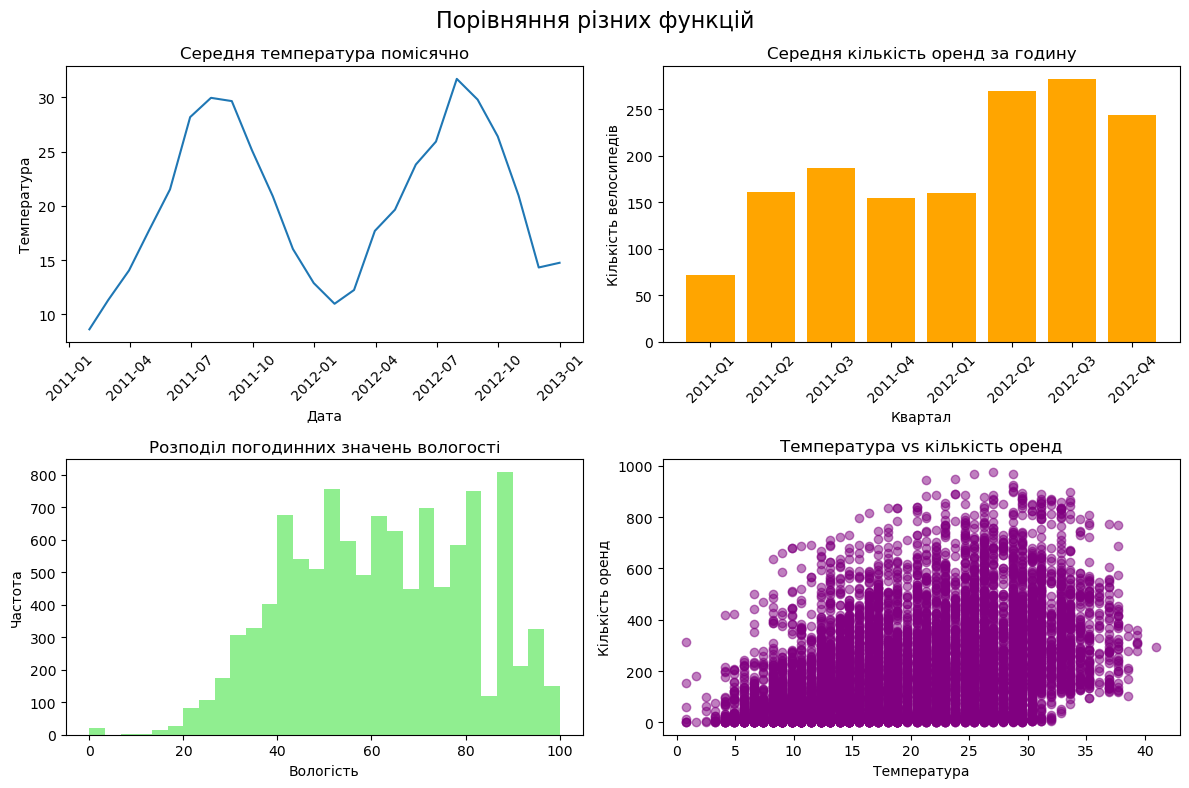

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(df['temp'].resample('ME').mean())
ax[0, 0].set_title('Cередня температура помісячно')
ax[0, 0].set_xlabel('Дата')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].tick_params(axis='x', rotation=45)

ax[0, 1].bar([f"{d.year}-Q{d.quarter}" for d in quarterly.index], df['count'].resample('QE').mean().values, color='orange')
ax[0, 1].set_title('Cередня кількість оренд за годину')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Кількість велосипедів')
ax[0, 1].tick_params(axis='x', rotation=45)

ax[1, 0].hist(df['humidity'],bins=30, color='lightgreen')
ax[1, 0].set_title('Розподіл погодинних значень вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

ax[1, 1].scatter(df['temp'], df['count'], alpha = 0.5, color='purple')
ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')

fig.suptitle('Порівняння різних функцій', fontsize=16)
plt.tight_layout()
plt.show();